<a href="https://colab.research.google.com/github/EnigmaValdez/data-pipelines/blob/main/Local_Service_Pricing_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Simulate a structured dataset representing local service tiers / competitor offerings
# (In production, this is where your BeautifulSoup/Requests extraction feeds into)
data = {
    'Service_Provider': ['Alpha Tech Solutions', 'Beta Digital Ops', 'Gamma Data Labs', 'Delta Analytics Co',
                         'Epsilon Cloud Services', 'Zeta Growth Partners', 'Eta Systems Inc', 'Theta Business Intelligence'],
    'Service_Tier': ['Standard', 'Enterprise', 'Standard', 'Enterprise', 'Standard', 'Enterprise', 'Standard', 'Enterprise'],
    'Monthly_Fee_USD': [1200, 4500, 1500, 5000, 1100, 4200, 1350, 4800],
    'SLA_Response_Hours': [24, 4, 12, 2, 24, 4, 12, 2],
    'Client_Satisfaction_Score': [4.2, 4.8, 4.4, 4.9, 4.1, 4.7, 4.5, 4.9]
}

df = pd.DataFrame(data)

# 2. Data Cleaning & Sanitization (Applying RegEx / string formatting standards)
df['Service_Provider'] = df['Service_Provider'].astype(str).str.strip()

# 3. Feature Engineering: Calculate Value Metric (Satisfaction per $1,000 spent)
df['Value_Efficiency_Ratio'] = (df['Client_Satisfaction_Score'] / (df['Monthly_Fee_USD'] / 1000)).round(2)

print("--- Local Market Pricing & Efficiency Audit ---")
print(df.to_string(index=False))

# 4. Groupby Aggregation for Executive Insights
summary_table = df.groupby('Service_Tier').agg(
    Avg_Monthly_Fee=('Monthly_Fee_USD', 'mean'),
    Avg_Satisfaction=('Client_Satisfaction_Score', 'mean'),
    Provider_Count=('Service_Provider', 'count')
).reset_index()

print("\n--- Market Segment Summary ---")
print(summary_table.to_string(index=False))

--- Local Market Pricing & Efficiency Audit ---
           Service_Provider Service_Tier  Monthly_Fee_USD  SLA_Response_Hours  Client_Satisfaction_Score  Value_Efficiency_Ratio
       Alpha Tech Solutions     Standard             1200                  24                        4.2                    3.50
           Beta Digital Ops   Enterprise             4500                   4                        4.8                    1.07
            Gamma Data Labs     Standard             1500                  12                        4.4                    2.93
         Delta Analytics Co   Enterprise             5000                   2                        4.9                    0.98
     Epsilon Cloud Services     Standard             1100                  24                        4.1                    3.73
       Zeta Growth Partners   Enterprise             4200                   4                        4.7                    1.12
            Eta Systems Inc     Standard         

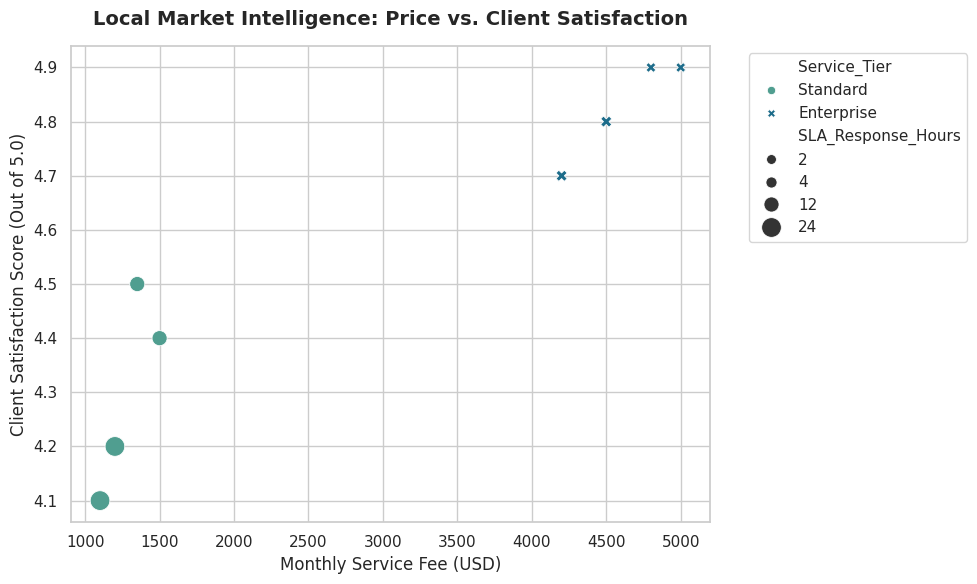

In [2]:
# Set visual style
sns.set_theme(style='whitegrid')
plt.figure(figsize=(10, 6))

# Create a scatter plot with regression line to show market positioning
sns.scatterplot(
    data=df,
    x='Monthly_Fee_USD',
    y='Client_Satisfaction_Score',
    hue='Service_Tier',
    size='SLA_Response_Hours',
    sizes=(50, 200),
    palette='crest',
    style='Service_Tier'
)

# Add clean titles and labels designed for executive clarity
plt.title('Local Market Intelligence: Price vs. Client Satisfaction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Monthly Service Fee (USD)', fontsize=12)
plt.ylabel('Client Satisfaction Score (Out of 5.0)', fontsize=12)

# Legend positioning
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()